In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/kaggle/input/datasets/manyadhamija/customer-data/Dataset (1).csv")

In [3]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [4]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [5]:
df['Review Rating'].fillna(df['Review Rating'].mean(), inplace=True)

/tmp/ipykernel_57/4130701081.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Review Rating'].fillna(df['Review Rating'].mean(), inplace=True)


In [6]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [7]:
df.dtypes

Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object

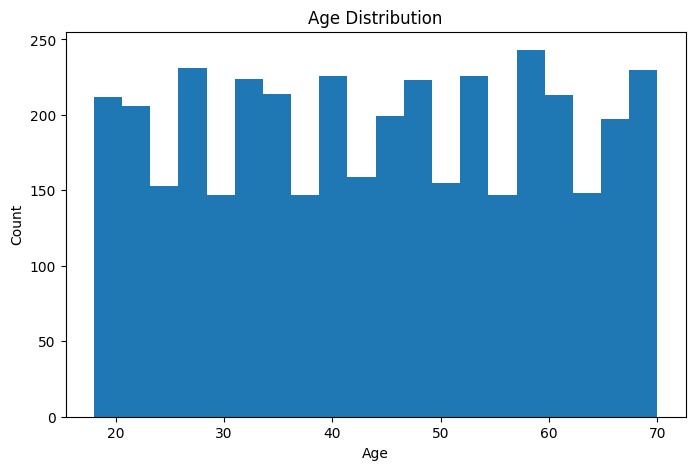

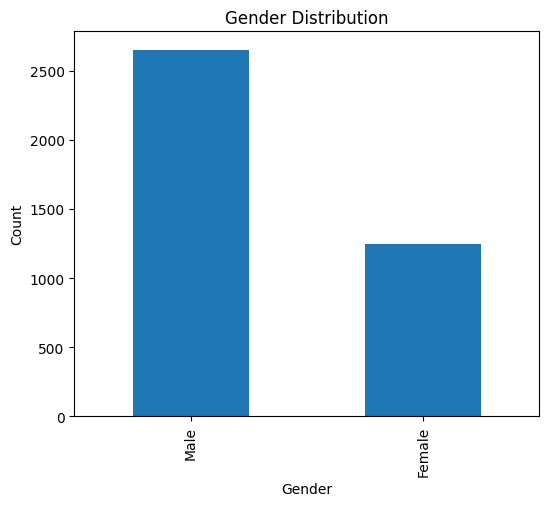

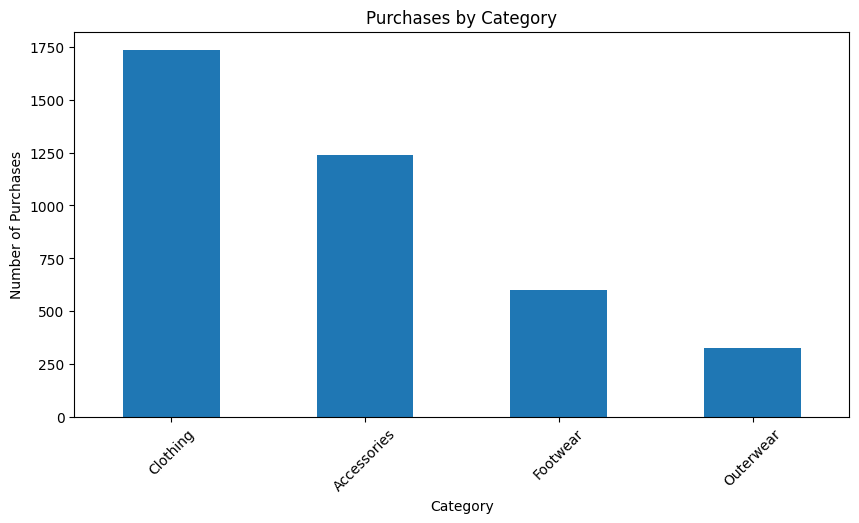

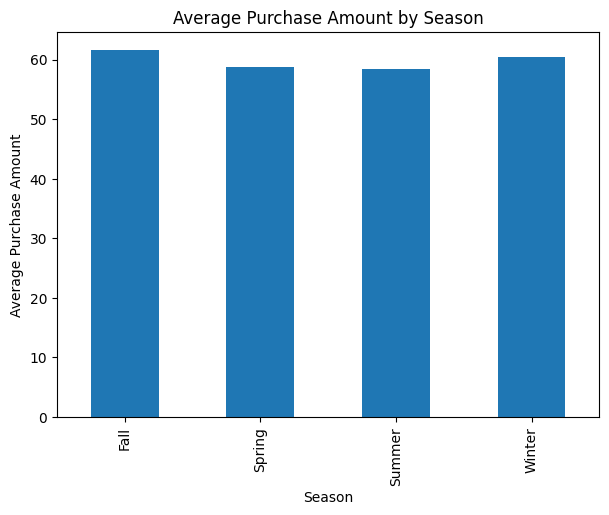

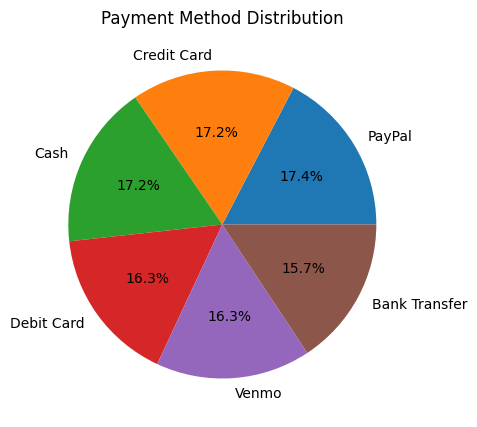

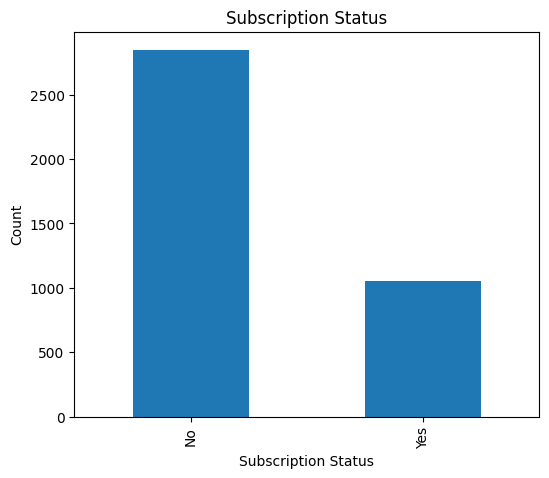

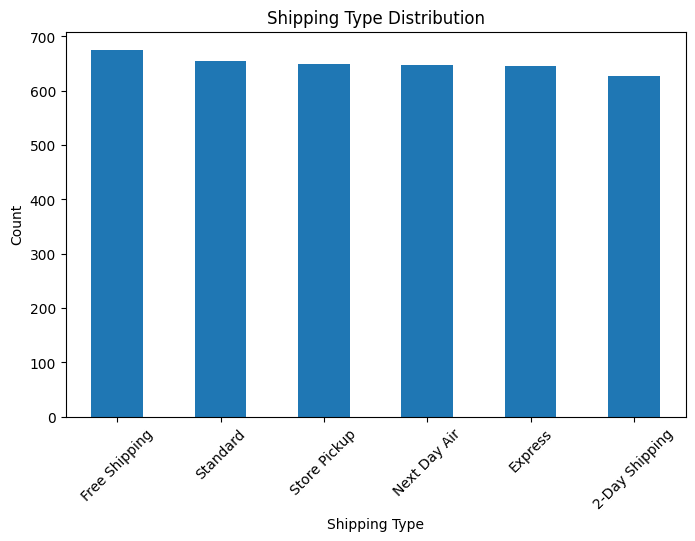

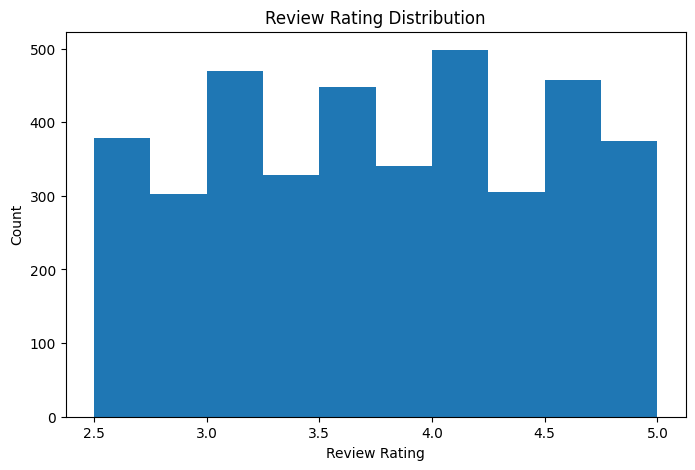

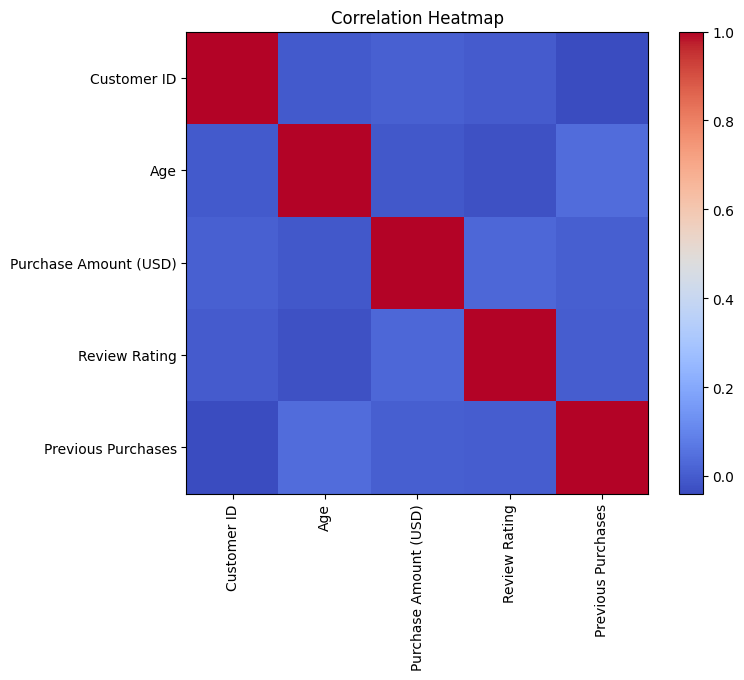

In [10]:
# -----------------------------
# 1. Age Distribution
# -----------------------------
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=20)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()


# -----------------------------
# 2. Gender Count
# -----------------------------
plt.figure(figsize=(6,5))
df['Gender'].value_counts().plot(kind='bar')
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Gender Distribution")
plt.show()


# -----------------------------
# 3. Category Wise Purchases
# -----------------------------
plt.figure(figsize=(10,5))
df['Category'].value_counts().plot(kind='bar')
plt.xlabel("Category")
plt.ylabel("Number of Purchases")
plt.title("Purchases by Category")
plt.xticks(rotation=45)
plt.show()


# -----------------------------
# 4. Purchase Amount by Season
# -----------------------------
season_purchase = df.groupby('Season')['Purchase Amount (USD)'].mean()

plt.figure(figsize=(7,5))
season_purchase.plot(kind='bar')
plt.xlabel("Season")
plt.ylabel("Average Purchase Amount")
plt.title("Average Purchase Amount by Season")
plt.show()


# -----------------------------
# 5. Payment Method Usage
# -----------------------------
plt.figure(figsize=(8,5))
df['Payment Method'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()


# -----------------------------
# 6. Subscription Status
# -----------------------------
plt.figure(figsize=(6,5))
df['Subscription Status'].value_counts().plot(kind='bar')
plt.xlabel("Subscription Status")
plt.ylabel("Count")
plt.title("Subscription Status")
plt.show()


# -----------------------------
# 7. Shipping Type Distribution
# -----------------------------
plt.figure(figsize=(8,5))
df['Shipping Type'].value_counts().plot(kind='bar')
plt.xlabel("Shipping Type")
plt.ylabel("Count")
plt.title("Shipping Type Distribution")
plt.xticks(rotation=45)
plt.show()


# -----------------------------
# 8. Review Rating Distribution
# -----------------------------
plt.figure(figsize=(8,5))
plt.hist(df['Review Rating'], bins=10)
plt.xlabel("Review Rating")
plt.ylabel("Count")
plt.title("Review Rating Distribution")
plt.show()


# -----------------------------
# 9. Correlation Heatmap
# -----------------------------
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8,6))
plt.imshow(numeric_df.corr(), cmap='coolwarm')

plt.colorbar()
plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=90)
plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)

plt.title("Correlation Heatmap")
plt.show()

In [11]:
df.groupby('Discount Applied').size()

Discount Applied
No     2223
Yes    1677
dtype: int64

In [12]:
df.groupby('Frequency of Purchases').size()

Frequency of Purchases
Annually          572
Bi-Weekly         547
Every 3 Months    584
Fortnightly       542
Monthly           553
Quarterly         563
Weekly            539
dtype: int64

In [14]:
# Annualized frequency
frequency_map = {
    "Weekly": 52,
    "Bi-Weekly": 26,
    "Fortnightly": 26,
    "Monthly": 12,
    "Quarterly": 4,
    "Every 3 Months": 4,
    "Annually": 1
}

df["purchase_frequency_annual"] = (
    df["Frequency of Purchases"].map(frequency_map)
)

# Total purchases
df["purchase_count"] = (
    df["Previous Purchases"] + 1
)

# Repeat purchase ratio
df["repeat_purchase_ratio"] = (
    df["Previous Purchases"] / df["purchase_count"]
)

# Estimated lifetime spend
df["estimated_total_spend"] = (
    df["Purchase Amount (USD)"] * df["purchase_count"]
)

# Average order value proxy
df["avg_spend_per_purchase"] = (
    df["estimated_total_spend"] / df["purchase_count"]
)

In [15]:
# Promo usage
df["promo_used_flag"] = np.where(
    (df["Discount Applied"] == "Yes") |
    (df["Promo Code Used"] == "Yes"),
    1,
    0
)

# Organic customer
df["organic_customer_flag"] = np.where(
    df["promo_used_flag"] == 0,
    1,
    0
)

# Discount dependency score
df["discount_dependency_score"] = (
    df["promo_used_flag"] * 100
)

# Low dependency flag
df["low_promo_dependency_flag"] = np.where(
    df["promo_used_flag"] == 0,
    1,
    0
)

In [16]:
# Satisfaction flag
df["satisfaction_flag"] = np.where(
    df["Review Rating"] >= 4,
    1,
    0
)

# Rating category
df["rating_segment"] = pd.cut(
    df["Review Rating"],
    bins=[0, 2, 3, 4, 5],
    labels=[
        "Poor",
        "Average",
        "Good",
        "Excellent"
    ]
)

In [17]:
# Subscription
df["subscription_flag"] = np.where(
    df["Subscription Status"] == "Yes",
    1,
    0
)

# Engagement score
df["engagement_score"] = (
    0.6 * df["subscription_flag"] +
    0.4 * df["satisfaction_flag"]
) * 100

In [18]:
# Percentile ranks
df["purchase_count_percentile"] = (
    df["purchase_count"].rank(pct=True)
)

df["frequency_percentile"] = (
    df["purchase_frequency_annual"].rank(pct=True)
)

# Behavioral loyalty score
df["behavioral_loyalty_score"] = (
    0.45 * df["purchase_count_percentile"]
    + 0.35 * df["frequency_percentile"]
    + 0.20 * df["repeat_purchase_ratio"]
) * 100

# Loyalty flag
df["behavioral_loyalty_flag"] = np.where(
    df["behavioral_loyalty_score"] >=
    df["behavioral_loyalty_score"].quantile(0.75),
    1,
    0
)

In [19]:
# Percentiles
df["spend_percentile"] = (
    df["estimated_total_spend"].rank(pct=True)
)

df["aov_percentile"] = (
    df["Purchase Amount (USD)"].rank(pct=True)
)

df["rating_percentile"] = (
    df["Review Rating"].rank(pct=True)
)

# Value-quality loyalty
df["value_quality_loyalty_score"] = (
    0.40 * df["spend_percentile"]
    + 0.25 * df["aov_percentile"]
    + 0.20 * df["rating_percentile"]
    + 0.15 * df["low_promo_dependency_flag"]
) * 100

# High-value loyalty
df["value_quality_loyalty_flag"] = np.where(
    df["value_quality_loyalty_score"] >=
    df["value_quality_loyalty_score"].quantile(0.75),
    1,
    0
)

In [20]:
# Age groups
df["age_group"] = pd.cut(
    df["Age"],
    bins=[0, 18, 25, 35, 45, 60, 100],
    labels=[
        "Teen",
        "18-25",
        "26-35",
        "36-45",
        "46-60",
        "60+"
    ]
)

In [21]:
# Spending tiers
df["spending_tier"] = pd.qcut(
    df["estimated_total_spend"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Premium"
    ]
)

# Loyalty tiers
df["loyalty_tier"] = pd.qcut(
    df["behavioral_loyalty_score"],
    q=4,
    labels=[
        "Bronze",
        "Silver",
        "Gold",
        "Elite"
    ]
)

In [22]:
conditions = [

    (
        (df["behavioral_loyalty_flag"] == 1) &
        (df["promo_used_flag"] == 0)
    ),

    (
        (df["behavioral_loyalty_flag"] == 1) &
        (df["promo_used_flag"] == 1)
    ),

    (
        (df["behavioral_loyalty_flag"] == 0) &
        (df["promo_used_flag"] == 1)
    ),

    (
        (df["behavioral_loyalty_flag"] == 0) &
        (df["promo_used_flag"] == 0)
    )
]

choices = [
    "True Loyalist",
    "Discount Loyalist",
    "Discount Hunter",
    "Casual Customer"
]

df["customer_archetype"] = np.select(
    conditions,
    choices,
    default="Other"
)

In [23]:
df["ideal_customer_flag"] = np.where(

    (
        (df["behavioral_loyalty_flag"] == 1)
        &
        (df["value_quality_loyalty_flag"] == 1)
        &
        (df["promo_used_flag"] == 0)
        &
        (df["subscription_flag"] == 1)
    ),

    1,
    0
)